Project root: e:\github\BTC-and-ETH-Data-Analyst-and-Prediction


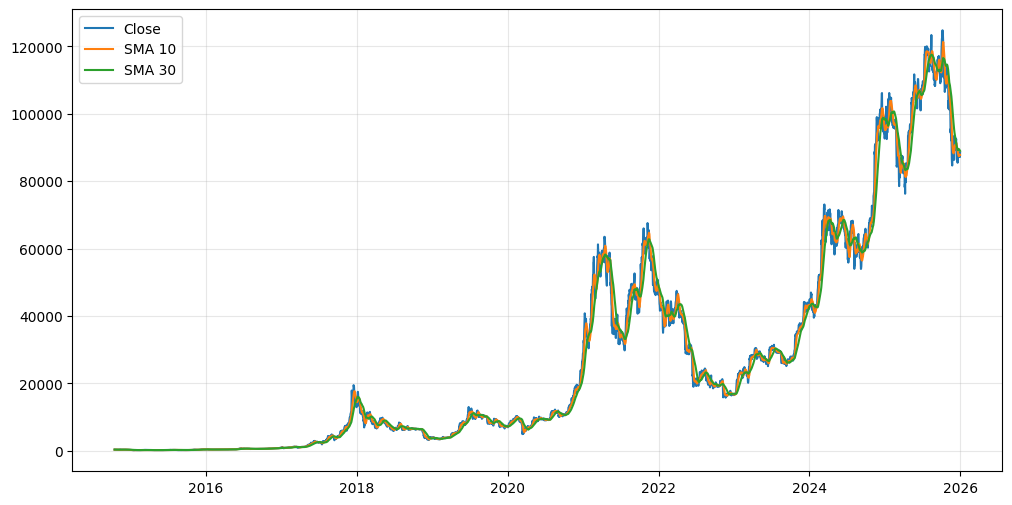

In [1]:
from pathlib import Path
import sys

current_dir = Path.cwd()

if (current_dir / "src").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "src").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not locate project root containing 'src'."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import clean_market_data
from src.feature_engineering import (
    add_technical_indicators,
    create_sequences
)

df = pd.read_csv(
    PROJECT_ROOT / "data/sample/test_crypto_data.csv"
)

df = clean_market_data(df)

featured_df = add_technical_indicators(df)

featured_df.head()

indicator_columns = [
    "SMA_10",
    "SMA_30",
    "EMA_5",
    "EMA_20",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

featured_df[indicator_columns].describe()

btc = featured_df[
    featured_df["Asset"] == "BTC-USD"
].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    btc["Date"],
    btc["Close"],
    label="Close"
)

plt.plot(
    btc["Date"],
    btc["SMA_10"],
    label="SMA 10"
)

plt.plot(
    btc["Date"],
    btc["SMA_30"],
    label="SMA 30"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()
